In [1]:
import pandas as pd
import numpy as np
import scipy.stats as sts
import matplotlib.pyplot as plt
import seaborn as sns

**Очистим данные**

In [2]:
# Загрузим таблицу (с данными по платежам)

df_data = pd.read_excel('groups_payments_data.xlsx', sheet_name = 'Данные')
df_data.info()
df_data.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 37989 entries, 0 to 37988
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_order     37989 non-null  int64         
 1   id_client    37401 non-null  float64       
 2   amt_payment  35845 non-null  float64       
 3   dtime_pay    35560 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 1.2 MB


,id_order,id_client,amt_payment,dtime_pay
0,100238,194569.0,5373.0,2022-10-28 04:05:15.221
1,100242,191056.0,4151.0,2022-08-01 02:42:54.992
2,100249,200049.0,5688.0,2022-08-24 12:45:12.744
3,100258,206161.0,4330.0,2022-12-09 15:13:26.437
4,100267,190945.0,5488.0,2022-08-03 02:07:31.468


In [3]:
# Обработаем её доведя до пригодного к дальнейшему анализу вида

df_data = df_data[df_data['id_client'].isnull() == False]
df_data['amt_payment'] = df_data['amt_payment'].fillna(df_data['amt_payment'].median())
df_data['dtime_pay'] = df_data['dtime_pay'].fillna(df_data['dtime_pay'].mode()[0])
df_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 37401 entries, 0 to 37988
Data columns (total 4 columns):
 #   Column       Non-Null Count  Dtype         
---  ------       --------------  -----         
 0   id_order     37401 non-null  int64         
 1   id_client    37401 non-null  float64       
 2   amt_payment  37401 non-null  float64       
 3   dtime_pay    37401 non-null  datetime64[ns]
dtypes: datetime64[ns](1), float64(2), int64(1)
memory usage: 1.4 MB


In [4]:
# Загрузим следующую (клиенты)

df_clients = pd.read_excel('groups_payments_data.xlsx', sheet_name = 'Clients')
df_clients.info()
df_clients.head()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55605 entries, 0 to 55604
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id_client         55605 non-null  int64         
 1   dtime_ad          55356 non-null  datetime64[ns]
 2   nflag_test        55605 non-null  int64         
 3   id_trading_point  55605 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 1.7 MB


,id_client,dtime_ad,nflag_test,id_trading_point
0,180844,2022-06-08 18:38:41.414,0,212
1,193942,NaT,0,13
2,226069,2022-07-11 16:28:38.511,1,54
3,183981,2022-06-16 12:23:59.289,1,991
4,322530,2022-07-08 08:56:08.714,0,1015


In [5]:
# Приведем к подходящему виду содержимое

df_clients = df_clients.dropna()
df_clients.info()

<class 'pandas.core.frame.DataFrame'>
Index: 55356 entries, 0 to 55604
Data columns (total 4 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id_client         55356 non-null  int64         
 1   dtime_ad          55356 non-null  datetime64[ns]
 2   nflag_test        55356 non-null  int64         
 3   id_trading_point  55356 non-null  int64         
dtypes: datetime64[ns](1), int64(3)
memory usage: 2.1 MB


In [6]:
# Так же выгрузим и последнюю таблицу с городами, здесь уже поправки не требуются

df_reg = pd.read_excel('groups_payments_data.xlsx', sheet_name = 'Region_dict')
df_reg.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 66 entries, 0 to 65
Data columns (total 2 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   id_trading_point  66 non-null     int64 
 1   city              66 non-null     object
dtypes: int64(1), object(1)
memory usage: 1.2+ KB


**Количество торговых точек в каждом городе**

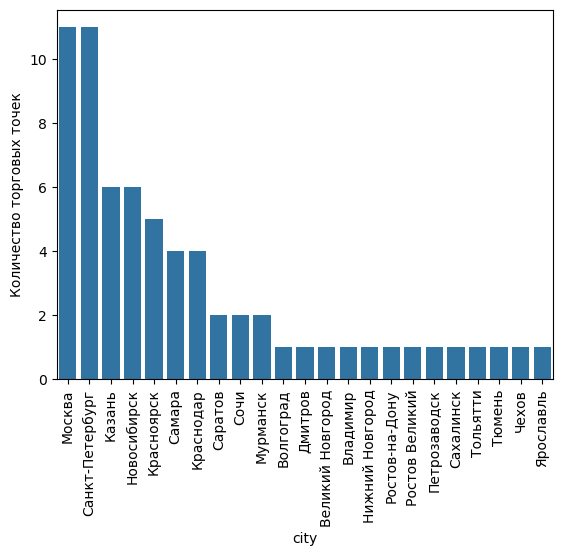

In [7]:
df_reg_gr = df_reg.groupby('city')['id_trading_point'].count().reset_index()\
                  .rename(columns = {'id_trading_point':'cnt_points'}).sort_values('cnt_points', ascending = False)

sns.barplot(data = df_reg_gr, y = 'cnt_points', x = 'city')
plt.ylabel('Количество торговых точек')
plt.xticks(rotation = 90)
plt.show()

**Соединим\сгруппируем таблицы для удобной работы**

In [8]:
# присоединим названия городов
df_clients_new = df_clients.merge(df_reg, on = 'id_trading_point', how = 'inner')
df_clients_new.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55356 entries, 0 to 55355
Data columns (total 5 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id_client         55356 non-null  int64         
 1   dtime_ad          55356 non-null  datetime64[ns]
 2   nflag_test        55356 non-null  int64         
 3   id_trading_point  55356 non-null  int64         
 4   city              55356 non-null  object        
dtypes: datetime64[ns](1), int64(3), object(1)
memory usage: 2.1+ MB


In [9]:
# группируем платежи клиентов
df_payments = df_data.groupby('id_client')['amt_payment'].sum().reset_index()\
                     .rename(columns = {'amt_payment':'sum_pay'}).sort_values('sum_pay', ascending = False)
df_payments

,id_client,sum_pay
15964,195273.0,43083.0
23634,203282.0,42222.0
1722,180362.0,38664.0
2427,181099.0,36982.0
15543,194825.0,36645.0
...,...,...
7258,186160.0,501.0
3543,182268.0,500.0
19726,199192.0,500.0
6033,184877.0,498.0


In [10]:
df_client_pays = df_payments.merge(df_clients_new, on = 'id_client', how = 'right')
df_client_pays.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55356 entries, 0 to 55355
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id_client         55356 non-null  float64       
 1   sum_pay           29463 non-null  float64       
 2   dtime_ad          55356 non-null  datetime64[ns]
 3   nflag_test        55356 non-null  int64         
 4   id_trading_point  55356 non-null  int64         
 5   city              55356 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 2.5+ MB


In [11]:
# Заполняем нулями Nan значения поля sum_pay
df_client_pays['sum_pay'] = df_client_pays['sum_pay'].fillna(0)
df_client_pays.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 55356 entries, 0 to 55355
Data columns (total 6 columns):
 #   Column            Non-Null Count  Dtype         
---  ------            --------------  -----         
 0   id_client         55356 non-null  float64       
 1   sum_pay           55356 non-null  float64       
 2   dtime_ad          55356 non-null  datetime64[ns]
 3   nflag_test        55356 non-null  int64         
 4   id_trading_point  55356 non-null  int64         
 5   city              55356 non-null  object        
dtypes: datetime64[ns](1), float64(2), int64(2), object(1)
memory usage: 2.5+ MB


In [12]:
# добавляем флаг факта платежа
df_client_pays['flag_pay'] = np.where(df_client_pays['sum_pay'] == 0, 0, 1)

**Работа со статистическими функциями**

In [13]:
def test_calc(r1, r2, alpha=0.05):
    
    # Вычисляем t-статистику и p-value
    t_stat, p_value = sts.ttest_ind(r1, r2, equal_var=False)
    
    print(f"Результаты t-теста Стьюдента:")
    print(f"t-статистика = {t_stat:.4f}")
    print(f"p-value = {p_value:.4f}")
    print(f"Уровень значимости alpha = {alpha}")
    
    if p_value < alpha:
        print("✅ Статистически значимая разница между средними значениями")
    else:
        print("❌ Нет статистически значимой разницы между средними значениями")
    
    return t_stat, p_value

def mann_whitney_func(r1, r2, alpha=0.05):
       
    # Вычисляем U-статистику и p-value
    u_stat, p_value = sts.mannwhitneyu(r1, r2)
    
    print(f"Результаты теста Манна-Уитни:")
    print(f"U-статистика = {u_stat:.4f}")
    print(f"p-value = {p_value:.4f}")
    print(f"Уровень значимости alpha = {alpha}")
    
    if p_value < alpha:
        print("✅ Статистически значимая разница между распределениями")
    else:
        print("❌ Нет статистически значимой разницы между распределениями")
    
    return u_stat, p_value


**Чистка неверно заполненных точек**

In [14]:
# Создаем пустой список для торговых точек, где в тестовой или контрольной группе не было платежей
empty_payment_points = []

# Создаем пустой список для торговых точек, где пустует контрольная или тестовая группа
empty_group_points = []

# Получаем список всех уникальных торговых точек
unique_trading_points = df_client_pays['id_trading_point'].unique()

# Первый цикл: точки, где в тестовой или контрольной группе не было заплачено ни одного рубля
for point in unique_trading_points:
    point_data = df_client_pays[df_client_pays['id_trading_point'] == point]
    
    # Сумма платежей в тестовой группе (nflag_test = 1)
    test_group_payments = point_data[point_data['nflag_test'] == 1]['sum_pay'].sum()
    
    # Сумма платежей в контрольной группе (nflag_test = 0)
    control_group_payments = point_data[point_data['nflag_test'] == 0]['sum_pay'].sum()
    
    # Если в одной из групп сумма платежей равна 0
    if test_group_payments == 0 or control_group_payments == 0:
        empty_payment_points.append(point)

print(f"Количество точек с нулевыми платежами в одной из групп: {len(empty_payment_points)}")

# Второй цикл: точки, где пустует контрольная или тестовая группа
for point in unique_trading_points:
    point_data = df_client_pays[df_client_pays['id_trading_point'] == point]
    
    # Количество клиентов в тестовой группе
    test_group_count = len(point_data[point_data['nflag_test'] == 1])
    
    # Количество клиентов в контрольной группе
    control_group_count = len(point_data[point_data['nflag_test'] == 0])
    
    # Если одна из групп пустая (нет клиентов)
    if test_group_count == 0 or control_group_count == 0:
        empty_group_points.append(point)

print(f"Количество точек с пустой одной из групп: {len(empty_group_points)}")

# Выводим примеры точек из каждого списка
if len(empty_payment_points) > 0:
    print(f"Примеры точек с нулевыми платежами: {empty_payment_points[:5]}")
    
if len(empty_group_points) > 0:
    print(f"Примеры точек с пустыми группами: {empty_group_points[:5]}")

# Создаем объединенный список всех проблемных точек
all_problem_points = list(set(empty_payment_points + empty_group_points))
print(f"\nОбщее количество проблемных точек: {len(all_problem_points)}")

Количество точек с нулевыми платежами в одной из групп: 12
Количество точек с пустой одной из групп: 8
Примеры точек с нулевыми платежами: [np.int64(1015), np.int64(866), np.int64(1099), np.int64(739), np.int64(228)]
Примеры точек с пустыми группами: [np.int64(1015), np.int64(866), np.int64(1099), np.int64(739), np.int64(228)]

Общее количество проблемных точек: 12


**Расчет общих результатов А/В-теста**

Исходное количество записей: 55356
Количество записей после очистки: 47005
Удалено записей: 8351

Количество клиентов в тестовой группе: 23334
Количество клиентов в контрольной группе: 23671


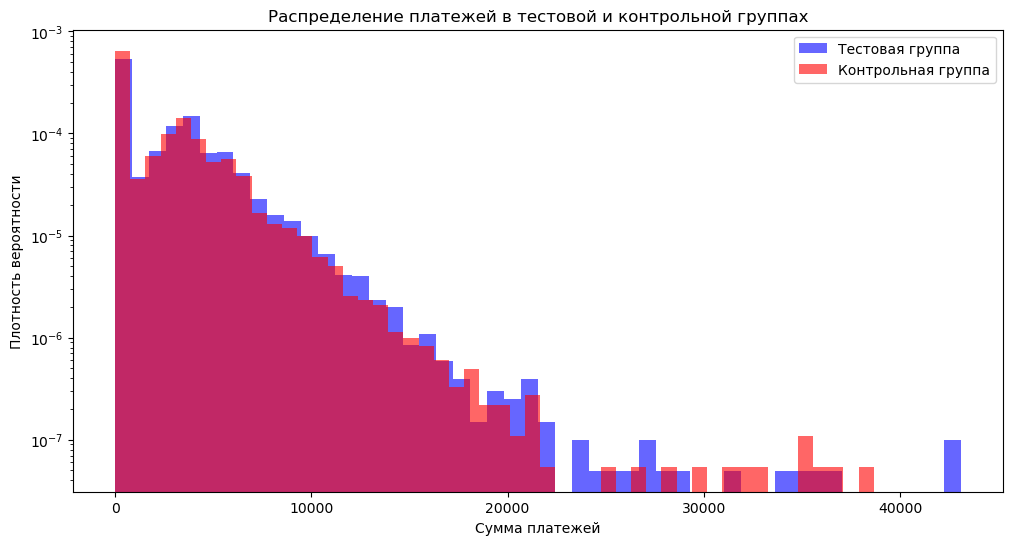


Базовая статистика по платежам:
Тестовая группа:
  Средний платеж: 2500.78
  Медианный платеж: 1901.50
  Стандартное отклонение: 3041.73
  Количество клиентов: 23334

Контрольная группа:
  Средний платеж: 2235.25
  Медианный платеж: 778.00
  Стандартное отклонение: 2905.48
  Количество клиентов: 23671

Конверсия в платеж:
  Тестовая группа: 0.5521 (55.21%)
  Контрольная группа: 0.5086 (50.86%)

ТЕСТ 1: Сравнение средних платежей
Результаты t-теста Стьюдента:
t-статистика = 9.6756
p-value = 0.0000
Уровень значимости alpha = 0.05
✅ Статистически значимая разница между средними значениями

ТЕСТ 2: Сравнение конверсии в платеж
Результаты t-теста Стьюдента:
t-статистика = 9.4421
p-value = 0.0000
Уровень значимости alpha = 0.05
✅ Статистически значимая разница между средними значениями

ТЕСТ 3: U-тест Манна-Уитни для распределения платежей
Результаты теста Манна-Уитни:
U-статистика = 290648913.0000
p-value = 0.0000
Уровень значимости alpha = 0.05
✅ Статистически значимая разница между распр

In [15]:
# Отбрасываем все проблемные торговые точки
df_cleaned = df_client_pays[~df_client_pays['id_trading_point'].isin(all_problem_points)]

print(f"Исходное количество записей: {len(df_client_pays)}")
print(f"Количество записей после очистки: {len(df_cleaned)}")
print(f"Удалено записей: {len(df_client_pays) - len(df_cleaned)}")

# Разделяем данные на тестовую и контрольную группы
test_group = df_cleaned[df_cleaned['nflag_test'] == 1]
control_group = df_cleaned[df_cleaned['nflag_test'] == 0]

print(f"\nКоличество клиентов в тестовой группе: {len(test_group)}")
print(f"Количество клиентов в контрольной группе: {len(control_group)}")

# Изображаем гистограмму платежей для обеих групп
plt.figure(figsize=(12, 6))

# Гистограмма для тестовой группы
plt.hist(test_group['sum_pay'], bins=50, alpha=0.6, color='blue', label='Тестовая группа', density=True)

# Гистограмма для контрольной группы
plt.hist(control_group['sum_pay'], bins=50, alpha=0.6, color='red', label='Контрольная группа', density=True)

plt.xlabel('Сумма платежей')
plt.ylabel('Плотность вероятности')
plt.title('Распределение платежей в тестовой и контрольной группах')
plt.legend()
plt.yscale('log')
plt.show()

# Базовая статистика по группам
print("\nБазовая статистика по платежам:")
print("Тестовая группа:")
print(f"  Средний платеж: {test_group['sum_pay'].mean():.2f}")
print(f"  Медианный платеж: {test_group['sum_pay'].median():.2f}")
print(f"  Стандартное отклонение: {test_group['sum_pay'].std():.2f}")
print(f"  Количество клиентов: {len(test_group)}")

print("\nКонтрольная группа:")
print(f"  Средний платеж: {control_group['sum_pay'].mean():.2f}")
print(f"  Медианный платеж: {control_group['sum_pay'].median():.2f}")
print(f"  Стандартное отклонение: {control_group['sum_pay'].std():.2f}")
print(f"  Количество клиентов: {len(control_group)}")

# Статистика по конверсии
test_conversion = test_group['flag_pay'].mean()
control_conversion = control_group['flag_pay'].mean()

print(f"\nКонверсия в платеж:")
print(f"  Тестовая группа: {test_conversion:.4f} ({test_conversion*100:.2f}%)")
print(f"  Контрольная группа: {control_conversion:.4f} ({control_conversion*100:.2f}%)")

# ТЕСТ 1: Сравниваем средние платежи
print("\n" + "="*60)
print("ТЕСТ 1: Сравнение средних платежей")
print("="*60)
t_stat_payment, p_value_payment = test_calc(test_group['sum_pay'], control_group['sum_pay'])

# ТЕСТ 2: Сравниваем конверсию в платеж
print("\n" + "="*60)
print("ТЕСТ 2: Сравнение конверсии в платеж")
print("="*60)
t_stat_conversion, p_value_conversion = test_calc(test_group['flag_pay'], control_group['flag_pay'])

# ТЕСТ 3: U-тест Манна-Уитни для распределения платежей
print("\n" + "="*60)
print("ТЕСТ 3: U-тест Манна-Уитни для распределения платежей")
print("="*60)
u_stat, u_p_value = mann_whitney_func(test_group['sum_pay'], control_group['sum_pay'])

# Дополнительная информация о разнице между группами
payment_diff = test_group['sum_pay'].mean() - control_group['sum_pay'].mean()
payment_diff_percent = (payment_diff / control_group['sum_pay'].mean()) * 100

conversion_diff = test_conversion - control_conversion
conversion_diff_percent = (conversion_diff / control_conversion) * 100

print("\n" + "="*60)
print("ДОПОЛНИТЕЛЬНАЯ ИНФОРМАЦИЯ:")
print("="*60)
print(f"Разница в средних платежах: {payment_diff:.2f} руб. ({payment_diff_percent:+.2f}%)")
print(f"Разница в конверсии: {conversion_diff:.4f} ({conversion_diff_percent:+.2f}%)")

# Выводы
print("\n" + "="*60)
print("ОСНОВНЫЕ ВЫВОДЫ:")
print("="*60)

if p_value_payment < 0.05:
    if payment_diff > 0:
        print("✅ Тестовая группа показывает СТАТИСТИЧЕСКИ ЗНАЧИМО более высокие средние платежи")
    else:
        print("✅ Тестовая группа показывает СТАТИСТИЧЕСКИ ЗНАЧИМО более низкие средние платежи")
else:
    print("❌ Нет статистически значимой разницы в средних платежах между группами")

if p_value_conversion < 0.05:
    if conversion_diff > 0:
        print("✅ Тестовая группа показывает СТАТИСТИЧЕСКИ ЗНАЧИМО более высокую конверсию")
    else:
        print("✅ Тестовая группа показывает СТАТИСТИЧЕСКИ ЗНАЧИМО более низкую конверсию")
else:
    print("❌ Нет статистически значимой разницы в конверсии между группами")

if u_p_value < 0.05:
    print("✅ Распределения платежей в группах СТАТИСТИЧЕСКИ ЗНАЧИМО различаются")
else:
    print("❌ Нет статистически значимого различия в распределениях платежей")

**Сегментированный анализ результатов**


АНАЛИЗ A/B ТЕСТА ДЛЯ ГОРОДА: МОСКВА
Клиентов в тестовой группе: 6134
Клиентов в контрольной группе: 6224

БАЗОВАЯ СТАТИСТИКА:
Средний платеж - Тест: 2409.78, Контроль: 2025.76
Конверсия - Тест: 0.5512, Контроль: 0.4974


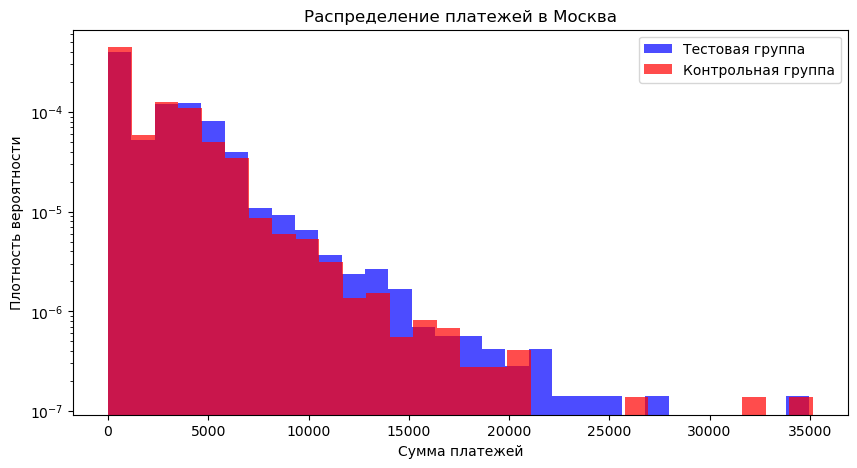


ТЕСТ 1: Сравнение средних платежей в Москва
Результаты t-теста Стьюдента:
t-статистика = 7.6681
p-value = 0.0000
Уровень значимости alpha = 0.05
✅ Статистически значимая разница между средними значениями

ТЕСТ 2: Сравнение конверсии в Москва
Результаты t-теста Стьюдента:
t-статистика = 5.9916
p-value = 0.0000
Уровень значимости alpha = 0.05
✅ Статистически значимая разница между средними значениями

ТЕСТ 3: U-тест Манна-Уитни для Москва
Результаты теста Манна-Уитни:
U-статистика = 20590643.0000
p-value = 0.0000
Уровень значимости alpha = 0.05
✅ Статистически значимая разница между распределениями

ОСНОВНЫЕ ВЫВОДЫ ДЛЯ МОСКВА:
Разница в платежах: +384.02 руб. (+18.96%)
Разница в конверсии: +0.0538 (+10.81%)
✅ СТАТИСТИЧЕСКИ ЗНАЧИМОЕ УВЕЛИЧЕНИЕ средних платежей
✅ СТАТИСТИЧЕСКИ ЗНАЧИМОЕ УВЕЛИЧЕНИЕ конверсии

АНАЛИЗ A/B ТЕСТА ДЛЯ ГОРОДА: САНКТ-ПЕТЕРБУРГ
Клиентов в тестовой группе: 4445
Клиентов в контрольной группе: 4434

БАЗОВАЯ СТАТИСТИКА:
Средний платеж - Тест: 2483.67, Контроль: 1940.95

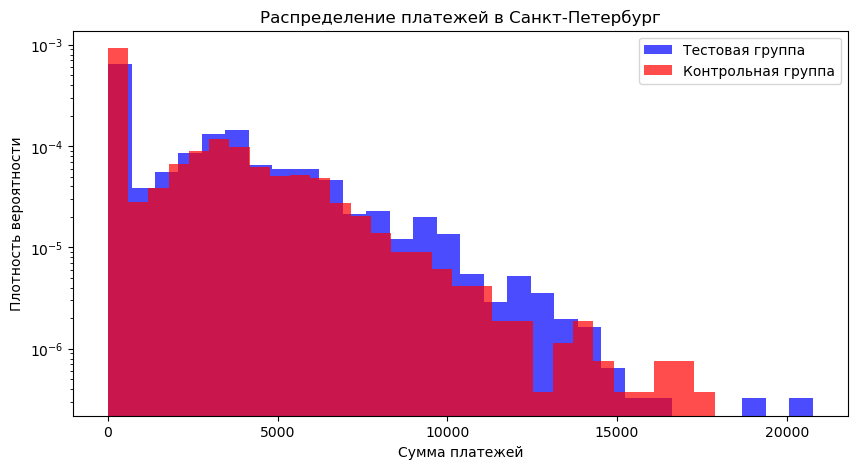


ТЕСТ 1: Сравнение средних платежей в Санкт-Петербург
Результаты t-теста Стьюдента:
t-статистика = 9.1878
p-value = 0.0000
Уровень значимости alpha = 0.05
✅ Статистически значимая разница между средними значениями

ТЕСТ 2: Сравнение конверсии в Санкт-Петербург
Результаты t-теста Стьюдента:
t-статистика = 9.8037
p-value = 0.0000
Уровень значимости alpha = 0.05
✅ Статистически значимая разница между средними значениями

ТЕСТ 3: U-тест Манна-Уитни для Санкт-Петербург
Результаты теста Манна-Уитни:
U-статистика = 10947975.5000
p-value = 0.0000
Уровень значимости alpha = 0.05
✅ Статистически значимая разница между распределениями

ОСНОВНЫЕ ВЫВОДЫ ДЛЯ САНКТ-ПЕТЕРБУРГ:
Разница в платежах: +542.72 руб. (+27.96%)
Разница в конверсии: +0.1035 (+22.84%)
✅ СТАТИСТИЧЕСКИ ЗНАЧИМОЕ УВЕЛИЧЕНИЕ средних платежей
✅ СТАТИСТИЧЕСКИ ЗНАЧИМОЕ УВЕЛИЧЕНИЕ конверсии

АНАЛИЗ ДЛЯ ОСТАЛЬНЫХ ГОРОДОВ
Количество городов для анализа: 16
Города: ['Красноярск', 'Мурманск', 'Казань', 'Ярославль', 'Саратов', 'Тольятти', 'Тю

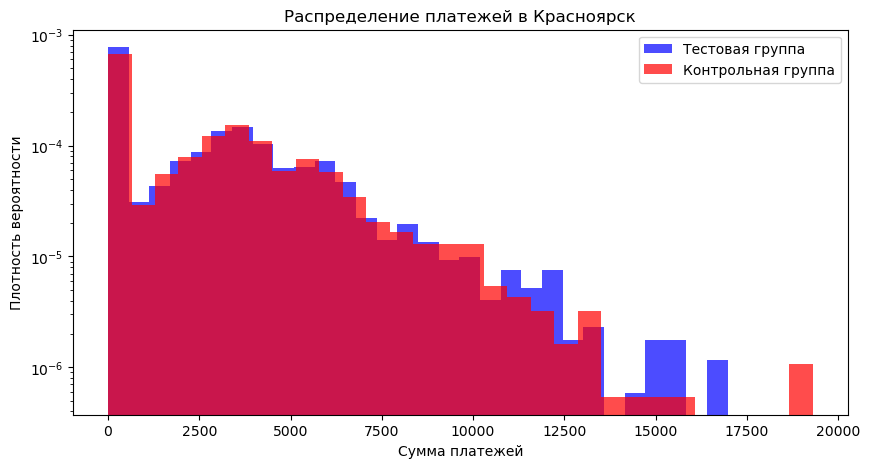


ТЕСТ 1: Сравнение средних платежей в Красноярск
Результаты t-теста Стьюдента:
t-статистика = 0.0250
p-value = 0.9801
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между средними значениями

ТЕСТ 2: Сравнение конверсии в Красноярск
Результаты t-теста Стьюдента:
t-статистика = -0.4642
p-value = 0.6425
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между средними значениями

ТЕСТ 3: U-тест Манна-Уитни для Красноярск
Результаты теста Манна-Уитни:
U-статистика = 4385805.0000
p-value = 0.7780
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между распределениями

ОСНОВНЫЕ ВЫВОДЫ ДЛЯ КРАСНОЯРСК:
Разница в платежах: +1.83 руб. (+0.07%)
Разница в конверсии: -0.0060 (-1.05%)
❌ Нет значимой разницы в средних платежах
❌ Нет значимой разницы в конверсии

АНАЛИЗ A/B ТЕСТА ДЛЯ ГОРОДА: МУРМАНСК
Клиентов в тестовой группе: 1055
Клиентов в контрольной группе: 1065

БАЗОВАЯ СТАТИСТИКА:
Средний платеж - Тест: 1911.32, Контроль: 1876.77
Конв

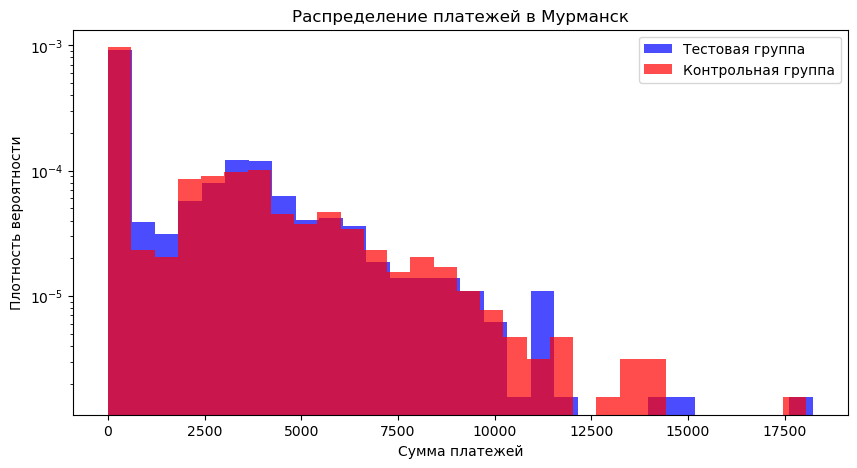


ТЕСТ 1: Сравнение средних платежей в Мурманск
Результаты t-теста Стьюдента:
t-статистика = 0.2938
p-value = 0.7690
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между средними значениями

ТЕСТ 2: Сравнение конверсии в Мурманск
Результаты t-теста Стьюдента:
t-статистика = 1.1540
p-value = 0.2486
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между средними значениями

ТЕСТ 3: U-тест Манна-Уитни для Мурманск
Результаты теста Манна-Уитни:
U-статистика = 573630.0000
p-value = 0.3530
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между распределениями

ОСНОВНЫЕ ВЫВОДЫ ДЛЯ МУРМАНСК:
Разница в платежах: +34.55 руб. (+1.84%)
Разница в конверсии: +0.0248 (+5.89%)
❌ Нет значимой разницы в средних платежах
❌ Нет значимой разницы в конверсии

АНАЛИЗ A/B ТЕСТА ДЛЯ ГОРОДА: КАЗАНЬ
Клиентов в тестовой группе: 2500
Клиентов в контрольной группе: 2577

БАЗОВАЯ СТАТИСТИКА:
Средний платеж - Тест: 2789.46, Контроль: 2668.59
Конверсия - Тес

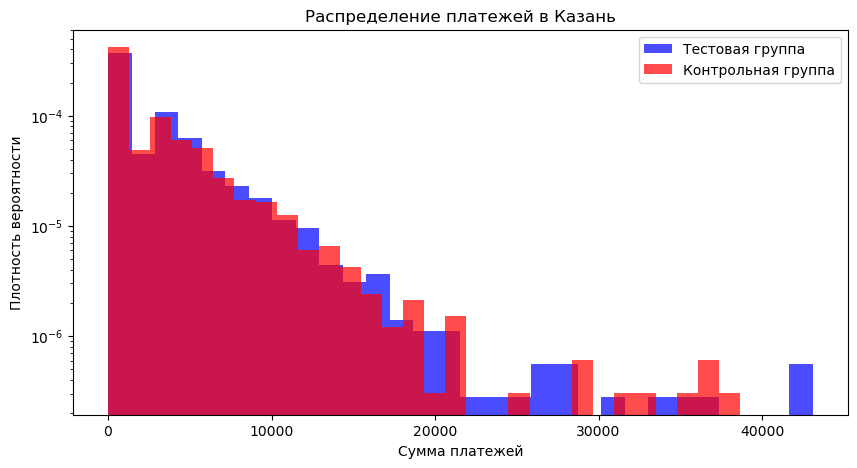


ТЕСТ 1: Сравнение средних платежей в Казань
Результаты t-теста Стьюдента:
t-статистика = 1.0452
p-value = 0.2960
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между средними значениями

ТЕСТ 2: Сравнение конверсии в Казань
Результаты t-теста Стьюдента:
t-статистика = 0.2848
p-value = 0.7758
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между средними значениями

ТЕСТ 3: U-тест Манна-Уитни для Казань
Результаты теста Манна-Уитни:
U-статистика = 3264033.0000
p-value = 0.3773
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между распределениями

ОСНОВНЫЕ ВЫВОДЫ ДЛЯ КАЗАНЬ:
Разница в платежах: +120.87 руб. (+4.53%)
Разница в конверсии: +0.0040 (+0.83%)
❌ Нет значимой разницы в средних платежах
❌ Нет значимой разницы в конверсии

АНАЛИЗ A/B ТЕСТА ДЛЯ ГОРОДА: ЯРОСЛАВЛЬ
Клиентов в тестовой группе: 557
Клиентов в контрольной группе: 529

БАЗОВАЯ СТАТИСТИКА:
Средний платеж - Тест: 2367.32, Контроль: 2398.37
Конверсия - Тест: 0.

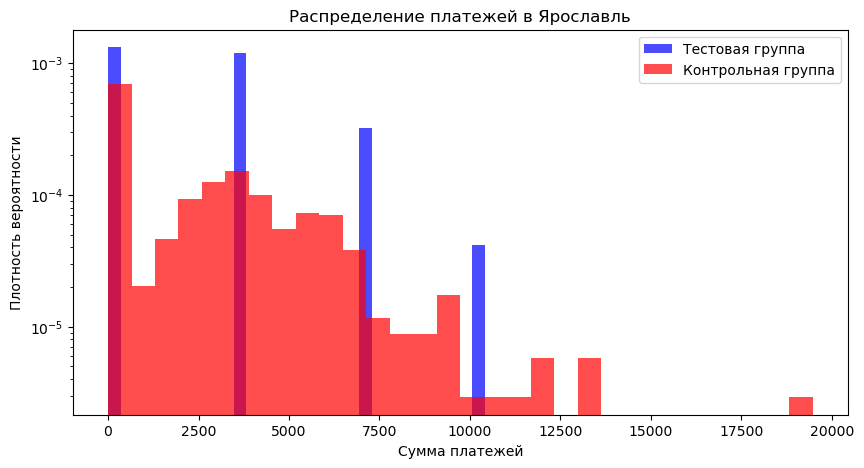


ТЕСТ 1: Сравнение средних платежей в Ярославль
Результаты t-теста Стьюдента:
t-статистика = -0.1929
p-value = 0.8471
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между средними значениями

ТЕСТ 2: Сравнение конверсии в Ярославль
Результаты t-теста Стьюдента:
t-статистика = -0.5117
p-value = 0.6090
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между средними значениями

ТЕСТ 3: U-тест Манна-Уитни для Ярославль
Результаты теста Манна-Уитни:
U-статистика = 147093.0000
p-value = 0.9621
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между распределениями

ОСНОВНЫЕ ВЫВОДЫ ДЛЯ ЯРОСЛАВЛЬ:
Разница в платежах: -31.05 руб. (-1.29%)
Разница в конверсии: -0.0155 (-2.77%)
❌ Нет значимой разницы в средних платежах
❌ Нет значимой разницы в конверсии

АНАЛИЗ A/B ТЕСТА ДЛЯ ГОРОДА: САРАТОВ
Клиентов в тестовой группе: 1013
Клиентов в контрольной группе: 1109

БАЗОВАЯ СТАТИСТИКА:
Средний платеж - Тест: 2597.30, Контроль: 2576.06
Конверси

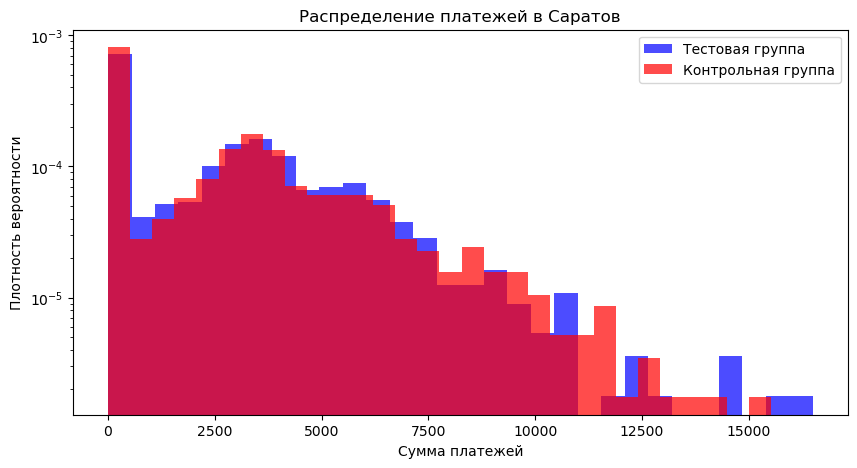


ТЕСТ 1: Сравнение средних платежей в Саратов
Результаты t-теста Стьюдента:
t-статистика = 0.1736
p-value = 0.8622
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между средними значениями

ТЕСТ 2: Сравнение конверсии в Саратов
Результаты t-теста Стьюдента:
t-статистика = 1.0977
p-value = 0.2725
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между средними значениями

ТЕСТ 3: U-тест Манна-Уитни для Саратов
Результаты теста Манна-Уитни:
U-статистика = 570168.0000
p-value = 0.5343
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между распределениями

ОСНОВНЫЕ ВЫВОДЫ ДЛЯ САРАТОВ:
Разница в платежах: +21.23 руб. (+0.82%)
Разница в конверсии: +0.0234 (+4.04%)
❌ Нет значимой разницы в средних платежах
❌ Нет значимой разницы в конверсии

АНАЛИЗ A/B ТЕСТА ДЛЯ ГОРОДА: ТОЛЬЯТТИ
Клиентов в тестовой группе: 190
Клиентов в контрольной группе: 167

БАЗОВАЯ СТАТИСТИКА:
Средний платеж - Тест: 2993.73, Контроль: 2439.46
Конверсия - Тест: 0

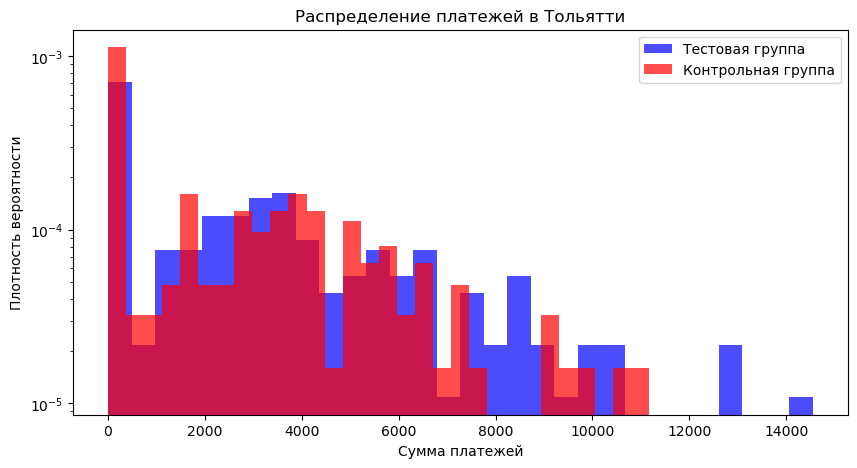


ТЕСТ 1: Сравнение средних платежей в Тольятти
Результаты t-теста Стьюдента:
t-статистика = 1.8089
p-value = 0.0713
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между средними значениями

ТЕСТ 2: Сравнение конверсии в Тольятти
Результаты t-теста Стьюдента:
t-статистика = 1.4948
p-value = 0.1359
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между средними значениями

ТЕСТ 3: U-тест Манна-Уитни для Тольятти
Результаты теста Манна-Уитни:
U-статистика = 17283.5000
p-value = 0.1340
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между распределениями

ОСНОВНЫЕ ВЫВОДЫ ДЛЯ ТОЛЬЯТТИ:
Разница в платежах: +554.27 руб. (+22.72%)
Разница в конверсии: +0.0771 (+13.27%)
❌ Нет значимой разницы в средних платежах
❌ Нет значимой разницы в конверсии

АНАЛИЗ A/B ТЕСТА ДЛЯ ГОРОДА: ТЮМЕНЬ
Клиентов в тестовой группе: 130
Клиентов в контрольной группе: 146

БАЗОВАЯ СТАТИСТИКА:
Средний платеж - Тест: 2070.52, Контроль: 1790.91
Конверсия - Тес

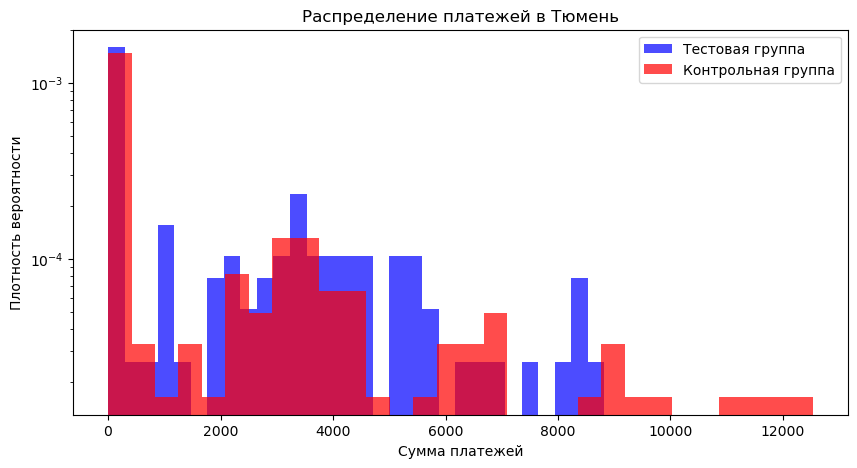


ТЕСТ 1: Сравнение средних платежей в Тюмень
Результаты t-теста Стьюдента:
t-статистика = 0.8666
p-value = 0.3869
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между средними значениями

ТЕСТ 2: Сравнение конверсии в Тюмень
Результаты t-теста Стьюдента:
t-статистика = 2.4668
p-value = 0.0143
Уровень значимости alpha = 0.05
✅ Статистически значимая разница между средними значениями

ТЕСТ 3: U-тест Манна-Уитни для Тюмень
Результаты теста Манна-Уитни:
U-статистика = 10717.0000
p-value = 0.0427
Уровень значимости alpha = 0.05
✅ Статистически значимая разница между распределениями

ОСНОВНЫЕ ВЫВОДЫ ДЛЯ ТЮМЕНЬ:
Разница в платежах: +279.60 руб. (+15.61%)
Разница в конверсии: +0.1472 (+38.38%)
❌ Нет значимой разницы в средних платежах
✅ СТАТИСТИЧЕСКИ ЗНАЧИМОЕ УВЕЛИЧЕНИЕ конверсии

АНАЛИЗ A/B ТЕСТА ДЛЯ ГОРОДА: ВОЛГОГРАД
Клиентов в тестовой группе: 657
Клиентов в контрольной группе: 703

БАЗОВАЯ СТАТИСТИКА:
Средний платеж - Тест: 2362.81, Контроль: 2646.18
Конверсия - Тест:

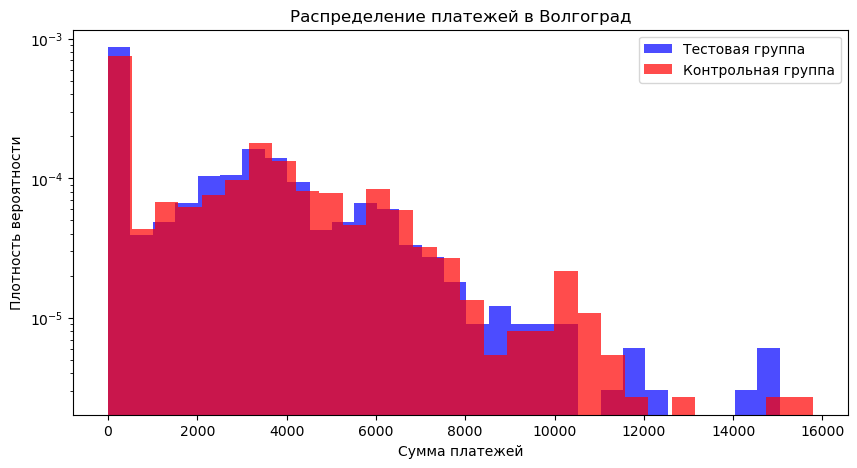


ТЕСТ 1: Сравнение средних платежей в Волгоград
Результаты t-теста Стьюдента:
t-статистика = -1.8804
p-value = 0.0603
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между средними значениями

ТЕСТ 2: Сравнение конверсии в Волгоград
Результаты t-теста Стьюдента:
t-статистика = -1.4905
p-value = 0.1363
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между средними значениями

ТЕСТ 3: U-тест Манна-Уитни для Волгоград
Результаты теста Манна-Уитни:
U-статистика = 217113.0000
p-value = 0.0475
Уровень значимости alpha = 0.05
✅ Статистически значимая разница между распределениями

ОСНОВНЫЕ ВЫВОДЫ ДЛЯ ВОЛГОГРАД:
Разница в платежах: -283.37 руб. (-10.71%)
Разница в конверсии: -0.0399 (-6.59%)
❌ Нет значимой разницы в средних платежах
❌ Нет значимой разницы в конверсии

АНАЛИЗ A/B ТЕСТА ДЛЯ ГОРОДА: СОЧИ
Клиентов в тестовой группе: 796
Клиентов в контрольной группе: 806

БАЗОВАЯ СТАТИСТИКА:
Средний платеж - Тест: 2366.86, Контроль: 2570.44
Конверсия - Тес

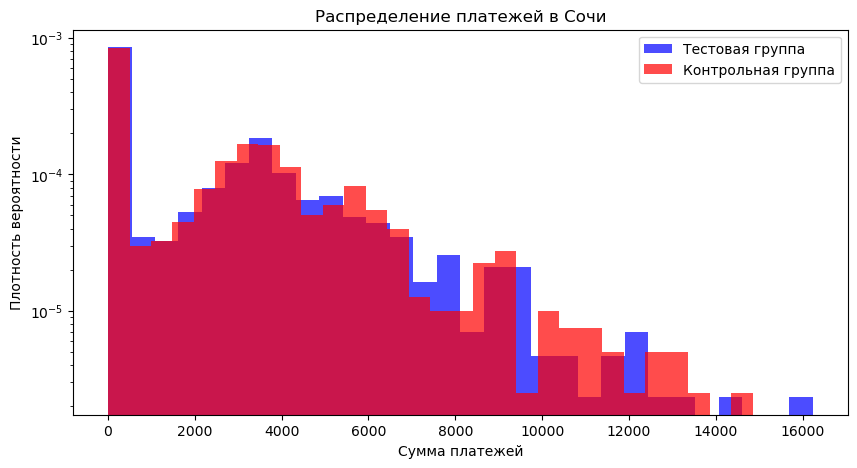


ТЕСТ 1: Сравнение средних платежей в Сочи
Результаты t-теста Стьюдента:
t-статистика = -1.4400
p-value = 0.1501
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между средними значениями

ТЕСТ 2: Сравнение конверсии в Сочи
Результаты t-теста Стьюдента:
t-статистика = -1.8328
p-value = 0.0670
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между средними значениями

ТЕСТ 3: U-тест Манна-Уитни для Сочи
Результаты теста Манна-Уитни:
U-статистика = 305679.5000
p-value = 0.0880
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между распределениями

ОСНОВНЫЕ ВЫВОДЫ ДЛЯ СОЧИ:
Разница в платежах: -203.58 руб. (-7.92%)
Разница в конверсии: -0.0454 (-7.79%)
❌ Нет значимой разницы в средних платежах
❌ Нет значимой разницы в конверсии

АНАЛИЗ A/B ТЕСТА ДЛЯ ГОРОДА: ВЛАДИМИР
Клиентов в тестовой группе: 509
Клиентов в контрольной группе: 608

БАЗОВАЯ СТАТИСТИКА:
Средний платеж - Тест: 2615.39, Контроль: 2137.15
Конверсия - Тест: 0.5619, Ко

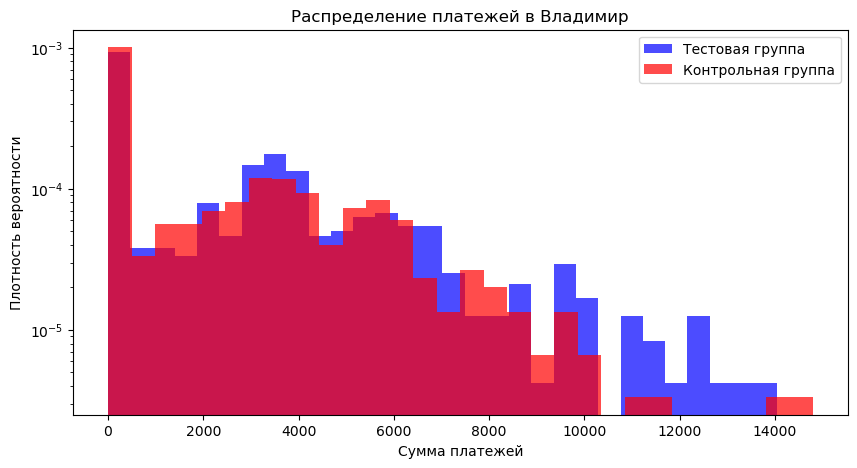


ТЕСТ 1: Сравнение средних платежей в Владимир
Результаты t-теста Стьюдента:
t-статистика = 2.7726
p-value = 0.0057
Уровень значимости alpha = 0.05
✅ Статистически значимая разница между средними значениями

ТЕСТ 2: Сравнение конверсии в Владимир
Результаты t-теста Стьюдента:
t-статистика = 1.9571
p-value = 0.0506
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между средними значениями

ТЕСТ 3: U-тест Манна-Уитни для Владимир
Результаты теста Манна-Уитни:
U-статистика = 166994.5000
p-value = 0.0159
Уровень значимости alpha = 0.05
✅ Статистически значимая разница между распределениями

ОСНОВНЫЕ ВЫВОДЫ ДЛЯ ВЛАДИМИР:
Разница в платежах: +478.25 руб. (+22.38%)
Разница в конверсии: +0.0586 (+11.64%)
✅ СТАТИСТИЧЕСКИ ЗНАЧИМОЕ УВЕЛИЧЕНИЕ средних платежей
❌ Нет значимой разницы в конверсии

АНАЛИЗ A/B ТЕСТА ДЛЯ ГОРОДА: САМАРА
Клиентов в тестовой группе: 802
Клиентов в контрольной группе: 846

БАЗОВАЯ СТАТИСТИКА:
Средний платеж - Тест: 3340.67, Контроль: 1763.54
Конверсия -

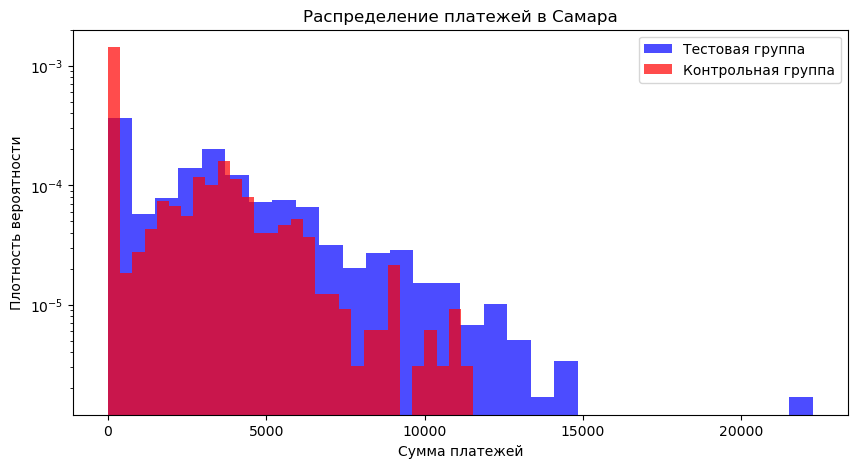


ТЕСТ 1: Сравнение средних платежей в Самара
Результаты t-теста Стьюдента:
t-статистика = 11.6427
p-value = 0.0000
Уровень значимости alpha = 0.05
✅ Статистически значимая разница между средними значениями

ТЕСТ 2: Сравнение конверсии в Самара
Результаты t-теста Стьюдента:
t-статистика = 12.1309
p-value = 0.0000
Уровень значимости alpha = 0.05
✅ Статистически значимая разница между средними значениями

ТЕСТ 3: U-тест Манна-Уитни для Самара
Результаты теста Манна-Уитни:
U-статистика = 446429.0000
p-value = 0.0000
Уровень значимости alpha = 0.05
✅ Статистически значимая разница между распределениями

ОСНОВНЫЕ ВЫВОДЫ ДЛЯ САМАРА:
Разница в платежах: +1577.13 руб. (+89.43%)
Разница в конверсии: +0.2815 (+62.67%)
✅ СТАТИСТИЧЕСКИ ЗНАЧИМОЕ УВЕЛИЧЕНИЕ средних платежей
✅ СТАТИСТИЧЕСКИ ЗНАЧИМОЕ УВЕЛИЧЕНИЕ конверсии

АНАЛИЗ A/B ТЕСТА ДЛЯ ГОРОДА: КРАСНОДАР
Клиентов в тестовой группе: 1024
Клиентов в контрольной группе: 1139

БАЗОВАЯ СТАТИСТИКА:
Средний платеж - Тест: 2740.86, Контроль: 2955.08
Конв

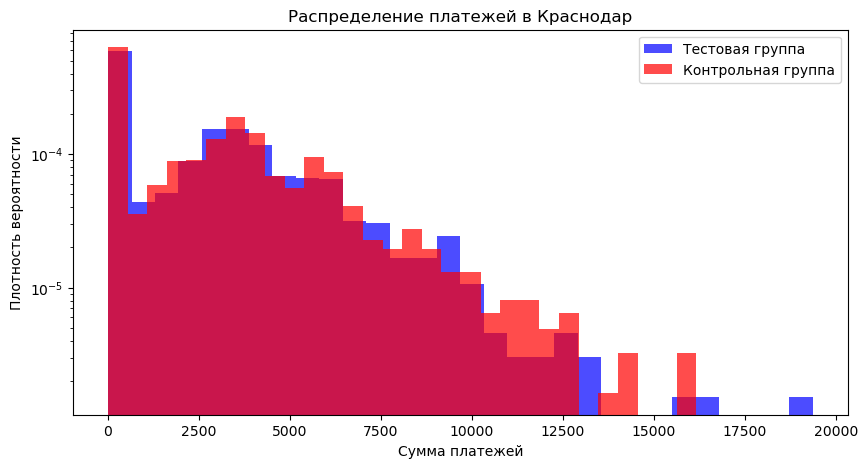


ТЕСТ 1: Сравнение средних платежей в Краснодар
Результаты t-теста Стьюдента:
t-статистика = -1.7118
p-value = 0.0871
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между средними значениями

ТЕСТ 2: Сравнение конверсии в Краснодар
Результаты t-теста Стьюдента:
t-статистика = -1.8824
p-value = 0.0599
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между средними значениями

ТЕСТ 3: U-тест Манна-Уитни для Краснодар
Результаты теста Манна-Уитни:
U-статистика = 556574.0000
p-value = 0.0606
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между распределениями

ОСНОВНЫЕ ВЫВОДЫ ДЛЯ КРАСНОДАР:
Разница в платежах: -214.23 руб. (-7.25%)
Разница в конверсии: -0.0388 (-5.86%)
❌ Нет значимой разницы в средних платежах
❌ Нет значимой разницы в конверсии

АНАЛИЗ A/B ТЕСТА ДЛЯ ГОРОДА: РОСТОВ-НА-ДОНУ
Клиентов в тестовой группе: 239
Клиентов в контрольной группе: 195

БАЗОВАЯ СТАТИСТИКА:
Средний платеж - Тест: 3092.51, Контроль: 3025.13
Ко

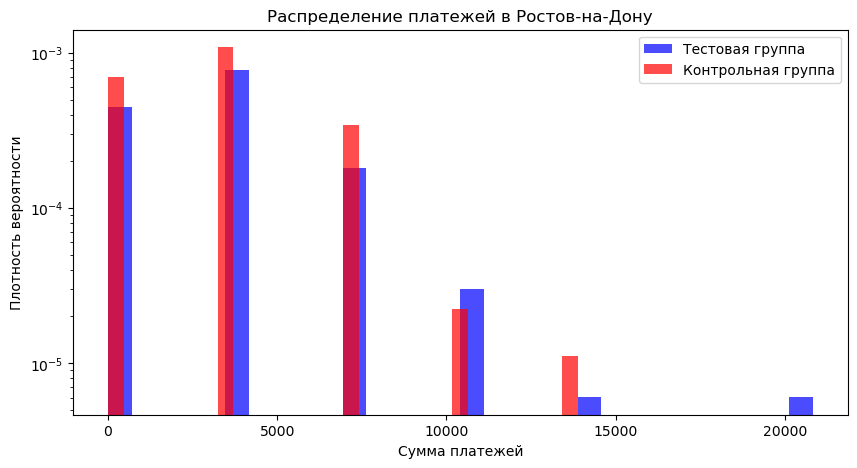


ТЕСТ 1: Сравнение средних платежей в Ростов-на-Дону
Результаты t-теста Стьюдента:
t-статистика = 0.2600
p-value = 0.7950
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между средними значениями

ТЕСТ 2: Сравнение конверсии в Ростов-на-Дону
Результаты t-теста Стьюдента:
t-статистика = 0.2989
p-value = 0.7651
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между средними значениями

ТЕСТ 3: U-тест Манна-Уитни для Ростов-на-Дону
Результаты теста Манна-Уитни:
U-статистика = 23316.5000
p-value = 0.9909
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между распределениями

ОСНОВНЫЕ ВЫВОДЫ ДЛЯ РОСТОВ-НА-ДОНУ:
Разница в платежах: +67.38 руб. (+2.23%)
Разница в конверсии: +0.0135 (+1.99%)
❌ Нет значимой разницы в средних платежах
❌ Нет значимой разницы в конверсии

АНАЛИЗ A/B ТЕСТА ДЛЯ ГОРОДА: САХАЛИНСК
Клиентов в тестовой группе: 75
Клиентов в контрольной группе: 78

БАЗОВАЯ СТАТИСТИКА:
Средний платеж - Тест: 1171.45, Контроль: 7

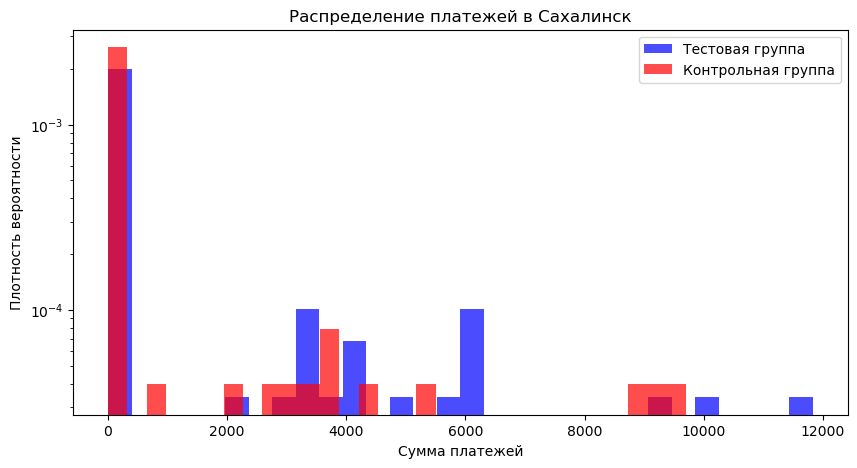


ТЕСТ 1: Сравнение средних платежей в Сахалинск
Результаты t-теста Стьюдента:
t-статистика = 1.1588
p-value = 0.2485
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между средними значениями

ТЕСТ 2: Сравнение конверсии в Сахалинск
Результаты t-теста Стьюдента:
t-статистика = 0.9455
p-value = 0.3460
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между средними значениями

ТЕСТ 3: U-тест Манна-Уитни для Сахалинск
Результаты теста Манна-Уитни:
U-статистика = 3120.0000
p-value = 0.2925
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между распределениями

ОСНОВНЫЕ ВЫВОДЫ ДЛЯ САХАЛИНСК:
Разница в платежах: +437.84 руб. (+59.68%)
Разница в конверсии: +0.0595 (+38.67%)
❌ Нет значимой разницы в средних платежах
❌ Нет значимой разницы в конверсии

АНАЛИЗ A/B ТЕСТА ДЛЯ ГОРОДА: ПЕТРОЗАВОДСК
Клиентов в тестовой группе: 93
Клиентов в контрольной группе: 74

БАЗОВАЯ СТАТИСТИКА:
Средний платеж - Тест: 970.11, Контроль: 844.05
Конверсия 

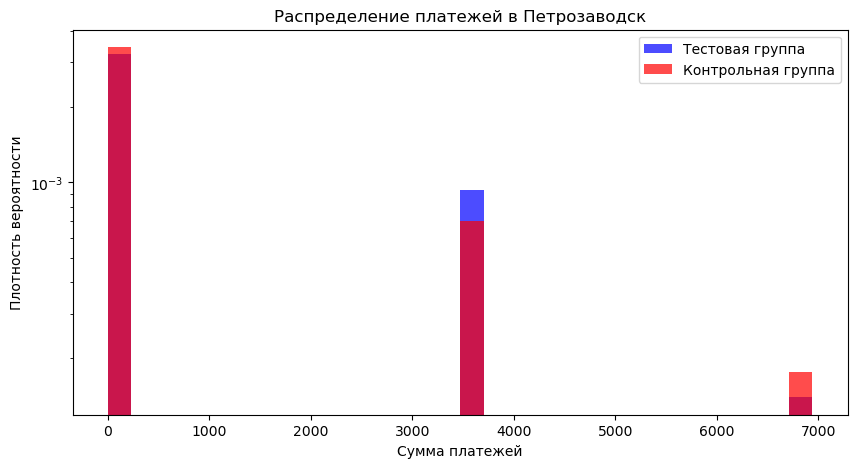


ТЕСТ 1: Сравнение средних платежей в Петрозаводск
Результаты t-теста Стьюдента:
t-статистика = 0.4498
p-value = 0.6535
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между средними значениями

ТЕСТ 2: Сравнение конверсии в Петрозаводск
Результаты t-теста Стьюдента:
t-статистика = 0.6853
p-value = 0.4941
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между средними значениями

ТЕСТ 3: U-тест Манна-Уитни для Петрозаводск
Результаты теста Манна-Уитни:
U-статистика = 3582.5000
p-value = 0.5334
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между распределениями

ОСНОВНЫЕ ВЫВОДЫ ДЛЯ ПЕТРОЗАВОДСК:
Разница в платежах: +126.05 руб. (+14.93%)
Разница в конверсии: +0.0446 (+22.01%)
❌ Нет значимой разницы в средних платежах
❌ Нет значимой разницы в конверсии

АНАЛИЗ A/B ТЕСТА ДЛЯ ГОРОДА: ДМИТРОВ
Клиентов в тестовой группе: 78
Клиентов в контрольной группе: 71

БАЗОВАЯ СТАТИСТИКА:
Средний платеж - Тест: 579.33, Контроль: 483.45
Кон

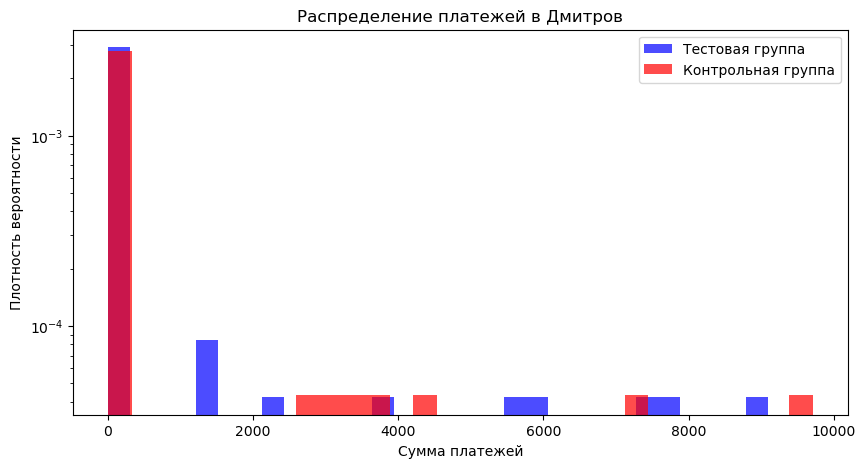


ТЕСТ 1: Сравнение средних платежей в Дмитров
Результаты t-теста Стьюдента:
t-статистика = 0.3329
p-value = 0.7397
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между средними значениями

ТЕСТ 2: Сравнение конверсии в Дмитров
Результаты t-теста Стьюдента:
t-статистика = 0.3296
p-value = 0.7421
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между средними значениями

ТЕСТ 3: U-тест Манна-Уитни для Дмитров
Результаты теста Манна-Уитни:
U-статистика = 2816.0000
p-value = 0.7423
Уровень значимости alpha = 0.05
❌ Нет статистически значимой разницы между распределениями

ОСНОВНЫЕ ВЫВОДЫ ДЛЯ ДМИТРОВ:
Разница в платежах: +95.88 руб. (+19.83%)
Разница в конверсии: +0.0168 (+17.03%)
❌ Нет значимой разницы в средних платежах
❌ Нет значимой разницы в конверсии


In [16]:
# Функция для анализа A/B теста в разрезе города
def analyze_city_ab_test(city_name, df):
    
    print(f"\n{'='*80}")
    print(f"АНАЛИЗ A/B ТЕСТА ДЛЯ ГОРОДА: {city_name.upper()}")
    print(f"{'='*80}")
    
    # Фильтруем данные по городу
    city_data = df[df['city'] == city_name]
    
    if len(city_data) == 0:
        print(f"❌ Нет данных для города {city_name}")
        return
    
    # Разделяем на тестовую и контрольную группы
    test_group_city = city_data[city_data['nflag_test'] == 1]
    control_group_city = city_data[city_data['nflag_test'] == 0]
    
    print(f"Клиентов в тестовой группе: {len(test_group_city)}")
    print(f"Клиентов в контрольной группе: {len(control_group_city)}")
    
    if len(test_group_city) == 0 or len(control_group_city) == 0:
        print("❌ Одна из групп пуста, анализ невозможен")
        return
    
    # Базовая статистика
    test_avg_payment = test_group_city['sum_pay'].mean()
    control_avg_payment = control_group_city['sum_pay'].mean()
    test_conversion = test_group_city['flag_pay'].mean()
    control_conversion = control_group_city['flag_pay'].mean()
    
    print(f"\nБАЗОВАЯ СТАТИСТИКА:")
    print(f"Средний платеж - Тест: {test_avg_payment:.2f}, Контроль: {control_avg_payment:.2f}")
    print(f"Конверсия - Тест: {test_conversion:.4f}, Контроль: {control_conversion:.4f}")
    
    # Гистограмма платежей
    plt.figure(figsize=(10, 5))
    
    plt.hist(test_group_city['sum_pay'], bins=30, alpha=0.7, color='blue', 
             label='Тестовая группа', density=True)
    plt.hist(control_group_city['sum_pay'], bins=30, alpha=0.7, color='red', 
             label='Контрольная группа', density=True)
    
    plt.xlabel('Сумма платежей')
    plt.ylabel('Плотность вероятности')
    plt.title(f'Распределение платежей в {city_name}')
    plt.legend()
    plt.yscale('log')
    plt.show()
    
    # Тест 1: Средние платежи
    print(f"\nТЕСТ 1: Сравнение средних платежей в {city_name}")
    t_stat_payment, p_value_payment = test_calc(test_group_city['sum_pay'], 
                                               control_group_city['sum_pay'])
    
    # Тест 2: Конверсия
    print(f"\nТЕСТ 2: Сравнение конверсии в {city_name}")
    t_stat_conv, p_value_conv = test_calc(test_group_city['flag_pay'], 
                                         control_group_city['flag_pay'])
    
    # Тест 3: U-тест Манна-Уитни
    print(f"\nТЕСТ 3: U-тест Манна-Уитни для {city_name}")
    u_stat, u_p_value = mann_whitney_func(test_group_city['sum_pay'], 
                                         control_group_city['sum_pay'])
    
    # Выводы
    payment_diff = test_avg_payment - control_avg_payment
    payment_diff_percent = (payment_diff / control_avg_payment) * 100 if control_avg_payment > 0 else 0
    
    conversion_diff = test_conversion - control_conversion
    conversion_diff_percent = (conversion_diff / control_conversion) * 100 if control_conversion > 0 else 0
    
    print(f"\nОСНОВНЫЕ ВЫВОДЫ ДЛЯ {city_name.upper()}:")
    print(f"Разница в платежах: {payment_diff:+.2f} руб. ({payment_diff_percent:+.2f}%)")
    print(f"Разница в конверсии: {conversion_diff:+.4f} ({conversion_diff_percent:+.2f}%)")
    
    if p_value_payment < 0.05:
        if payment_diff > 0:
            print("✅ СТАТИСТИЧЕСКИ ЗНАЧИМОЕ УВЕЛИЧЕНИЕ средних платежей")
        else:
            print("✅ СТАТИСТИЧЕСКИ ЗНАЧИМОЕ УМЕНЬШЕНИЕ средних платежей")
    else:
        print("❌ Нет значимой разницы в средних платежах")
    
    if p_value_conv < 0.05:
        if conversion_diff > 0:
            print("✅ СТАТИСТИЧЕСКИ ЗНАЧИМОЕ УВЕЛИЧЕНИЕ конверсии")
        else:
            print("✅ СТАТИСТИЧЕСКИ ЗНАЧИМОЕ УМЕНЬШЕНИЕ конверсии")
    else:
        print("❌ Нет значимой разницы в конверсии")
    
    return {
        'city': city_name,
        'test_size': len(test_group_city),
        'control_size': len(control_group_city),
        'test_avg_payment': test_avg_payment,
        'control_avg_payment': control_avg_payment,
        'test_conversion': test_conversion,
        'control_conversion': control_conversion,
        'payment_p_value': p_value_payment,
        'conversion_p_value': p_value_conv,
        'u_p_value': u_p_value,
        'payment_diff': payment_diff,
        'conversion_diff': conversion_diff
    }

# Анализ для Москвы
moscow_results = analyze_city_ab_test('Москва', df_cleaned)

# Анализ для Санкт-Петербурга
spb_results = analyze_city_ab_test('Санкт-Петербург', df_cleaned)

# Анализ для остальных городов
print(f"\n{'='*80}")
print("АНАЛИЗ ДЛЯ ОСТАЛЬНЫХ ГОРОДОВ")
print(f"{'='*80}")

# Получаем список всех городов (исключая Москву и СПб)
all_cities = df_cleaned['city'].unique()
other_cities = [city for city in all_cities if city not in ['Москва', 'Санкт-Петербург']]

print(f"Количество городов для анализа: {len(other_cities)}")
print(f"Города: {other_cities}")

# Список для хранения результатов
cities_results = []

# Анализ для каждого города
for city in other_cities:
    city_result = analyze_city_ab_test(city, df_cleaned)
    if city_result:  # Если анализ успешен
        cities_results.append(city_result)


**Отчет по A\B-тесту (обобщенный анализ и подготовка отчета)**

Начинаем анализ торговых точек...
Всего уникальных городов: 18
Всего уникальных торговых точек: 54

Анализ завершен. Обработано торговых точек: 54

Распределение торговых точек по лейблам:
  neutral: 34 точек (63.0%)
  positive: 18 точек (33.3%)
  negative: 2 точек (3.7%)


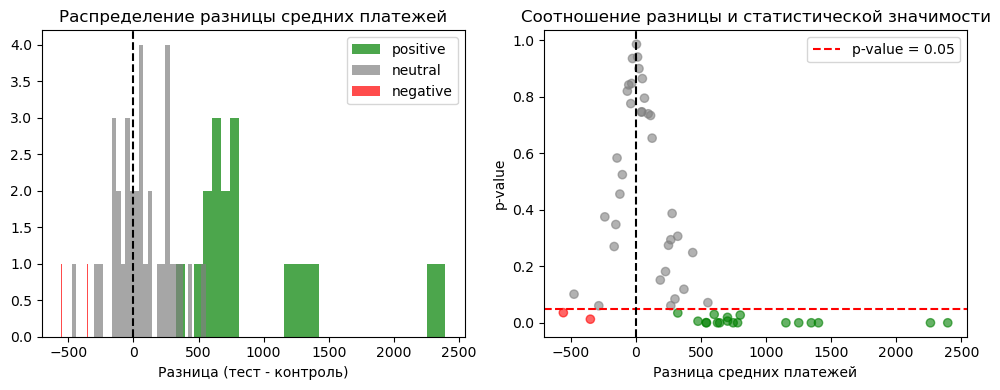


ДЕТАЛЬНЫЙ АНАЛИЗ ПО ГОРОДАМ

Статистика по городам:
                 total_points  positive_points   avg_diff  significant_ratio  \
city                                                                           
Владимир                    1                1   478.2465             1.0000   
Самара                      4                4  1537.3979             1.0000   
Санкт-Петербург            11                8   597.0999             0.7273   
Москва                     11                4   351.9288             0.4545   
Казань                      6                1   136.5158             0.1667   
Волгоград                   1                0  -283.3721             0.0000   
Красноярск                  5                0    22.1083             0.0000   
Мурманск                    2                0    30.8619             0.0000   
Краснодар                   2                0   -48.1946             0.5000   
Дмитров                     1                0    95.8826          

In [24]:
# Создаем детальную таблицу с сегментацией по городам и торговым точкам

def calculate_trading_point_metrics(city, trading_point, df):
    # Фильтруем данные по городу и торговой точке
    point_data = df[(df['city'] == city) & (df['id_trading_point'] == trading_point)]
    
    if len(point_data) == 0:
        return None
    
    # Разделяем на тестовую и контрольную группы
    test_group = point_data[point_data['nflag_test'] == 1]
    control_group = point_data[point_data['nflag_test'] == 0]
    
    # Базовые счетчики
    count_test = len(test_group)
    count_control = len(control_group)
    count_all = count_test + count_control
    
    # Если одна из групп пустая, пропускаем точку
    if count_test == 0 or count_control == 0:
        return None
    
    # Процент от общего количества наблюдений
    total_observations = len(df)
    percent_count = (count_all / total_observations) * 100
    
    # Средние платежи
    avg_payment_test = test_group['sum_pay'].mean()
    avg_payment_control = control_group['sum_pay'].mean()
    diff = avg_payment_test - avg_payment_control
    
    # Стандартные отклонения
    sigma_test = test_group['sum_pay'].std()
    sigma_control = control_group['sum_pay'].std()
    
    # T-тест
    try:
        ttest_stat, pvalue_ttest = sts.ttest_ind(
            test_group['sum_pay'], 
            control_group['sum_pay'], 
            equal_var=False,  # Используем Welch's t-test (не предполагаем равные дисперсии)
            nan_policy='omit'
        )
    except:
        ttest_stat, pvalue_ttest = np.nan, np.nan
    
    # Определяем лейбл
    if pvalue_ttest < 0.05:  # Статистически значимая разница
        if diff > 0:
            label = 'positive'
        else:
            label = 'negative'
    else:
        label = 'neutral'
    
    # Дополнительные метрики для более полного анализа
    # Медианные платежи (более устойчивы к выбросам)
    median_payment_test = test_group['sum_pay'].median()
    median_payment_control = control_group['sum_pay'].median()
    median_diff = median_payment_test - median_payment_control
    
    # Конверсия (доля платящих клиентов)
    conversion_test = test_group['flag_pay'].mean()
    conversion_control = control_group['flag_pay'].mean()
    conversion_diff = conversion_test - conversion_control
    
    # Общая сумма платежей
    total_payment_test = test_group['sum_pay'].sum()
    total_payment_control = control_group['sum_pay'].sum()
    total_diff = total_payment_test - total_payment_control
    
    # Коэффициент вариации (относительная изменчивость)
    cv_test = (sigma_test / avg_payment_test) if avg_payment_test > 0 else np.nan
    cv_control = (sigma_control / avg_payment_control) if avg_payment_control > 0 else np.nan
    
    return {
        'city': city,
        'id_trading_point': trading_point,
        'count_test': count_test,
        'count_control': count_control,
        'count_all': count_all,
        'percent_count': percent_count,
        'avg_payment_test': avg_payment_test,
        'avg_payment_control': avg_payment_control,
        'diff': diff,
        'sigma_test': sigma_test,
        'sigma_control': sigma_control,
        'ttest': ttest_stat,
        'pvalue_ttest': pvalue_ttest,
        'label': label,
        # Дополнительные метрики
        'median_payment_test': median_payment_test,
        'median_payment_control': median_payment_control,
        'median_diff': median_diff,
        'conversion_test': conversion_test,
        'conversion_control': conversion_control,
        'conversion_diff': conversion_diff,
        'total_payment_test': total_payment_test,
        'total_payment_control': total_payment_control,
        'total_diff': total_diff,
        'cv_test': cv_test,
        'cv_control': cv_control
    }

# Создаем пустой датафрейм для результатов
trading_points_results = []

print("Начинаем анализ торговых точек...")
print(f"Всего уникальных городов: {len(df_cleaned['city'].unique())}")
print(f"Всего уникальных торговых точек: {len(df_cleaned['id_trading_point'].unique())}")

# Запускаем цикл по всем городам и торговым точкам
cities = df_cleaned['city'].unique()

for city in cities:
    city_trading_points = df_cleaned[df_cleaned['city'] == city]['id_trading_point'].unique()
    
    for trading_point in city_trading_points:
        metrics = calculate_trading_point_metrics(city, trading_point, df_cleaned)
        if metrics is not None:
            trading_points_results.append(metrics)

# Создаем итоговый датафрейм
results_df = pd.DataFrame(trading_points_results)

print(f"\nАнализ завершен. Обработано торговых точек: {len(results_df)}")

# Анализ результатов по лейблам
label_counts = results_df['label'].value_counts()
print(f"\nРаспределение торговых точек по лейблам:")
for label, count in label_counts.items():
    percentage = (count / len(results_df)) * 100
    print(f"  {label}: {count} точек ({percentage:.1f}%)")

colors = {
    'positive': 'green',
    'neutral': 'gray',
    'negative': 'red'
}

# Визуализация распределения лейблов
plt.figure(figsize=(10, 4))

# График 1: Распределение разницы средних платежей
plt.subplot(1, 2, 1)
for label in ['positive', 'neutral', 'negative']:
    data = results_df[results_df['label'] == label]['diff']
    plt.hist(data, bins=30, alpha=0.7, label=label, color=colors[label])
plt.axvline(x=0, color='black', linestyle='--')
plt.title('Распределение разницы средних платежей')
plt.xlabel('Разница (тест - контроль)')
plt.legend()

# График 2: p-value vs разница
plt.subplot(1, 2, 2)
plt.scatter(results_df['diff'], results_df['pvalue_ttest'], 
           c=results_df['label'].map(colors), alpha=0.6)
plt.axhline(y=0.05, color='red', linestyle='--', label='p-value = 0.05')
plt.axvline(x=0, color='black', linestyle='--')
plt.xlabel('Разница средних платежей')
plt.ylabel('p-value')
plt.title('Соотношение разницы и статистической значимости')
plt.legend()

plt.tight_layout()
plt.show()

# Детальный анализ по городам
print(f"\n{'='*80}")
print("ДЕТАЛЬНЫЙ АНАЛИЗ ПО ГОРОДАМ")
print(f"{'='*80}")

city_summary = results_df.groupby('city').agg({
    'id_trading_point': 'count',
    'label': lambda x: (x == 'positive').sum(),
    'diff': 'mean',
    'pvalue_ttest': lambda x: (x < 0.05).mean(),  # Доля значимых тестов
    'count_all': 'sum'
}).round(4)

city_summary.columns = ['total_points', 'positive_points', 'avg_diff', 'significant_ratio', 'total_clients']

# Добавляем процент положительных точек
city_summary['positive_ratio'] = (city_summary['positive_points'] / city_summary['total_points']).round(4)

print("\nСтатистика по городам:")
print(city_summary.sort_values('positive_ratio', ascending=False))

# Анализ лучших и худших торговых точек
print(f"\n{'='*80}")
print("ТОП-10 ЛУЧШИХ ТОРГОВЫХ ТОЧЕК (наибольшая положительная разница)")
print(f"{'='*80}")
best_points = results_df[results_df['label'] == 'positive'].nlargest(10, 'diff')[
    ['city', 'id_trading_point', 'diff', 'pvalue_ttest', 'count_test', 'count_control']
]
print(best_points.round(4))

print(f"\n{'='*80}")
print("ТОП-2 ХУДШИЕ ТОРГОВЫЕ ТОЧКИ (наибольшая отрицательная разница)")
print(f"{'='*80}")
worst_points = results_df[results_df['label'] == 'negative'].nsmallest(10, 'diff')[
    ['city', 'id_trading_point', 'diff', 'pvalue_ttest', 'count_test', 'count_control']
]
print(worst_points.round(4))

# Анализ мощности тестов
print(f"\n{'='*80}")
print("АНАЛИЗ МОЩНОСТИ ТЕСТОВ")
print(f"{'='*80}")

# Точки с малым количеством наблюдений
small_sample_points = results_df[results_df['count_all'] < 10]
print(f"Торговых точек с малым количеством наблюдений (<10): {len(small_sample_points)}")

# Точки с высокой изменчивостью (CV > 1)
high_variance_points = results_df[
    (results_df['cv_test'] > 1) | (results_df['cv_control'] > 1)
]
print(f"Торговых точек с высокой изменчивостью (CV > 1): {len(high_variance_points)}")

# Рекомендации на основе анализа
print(f"\n{'='*80}")
print("РЕКОМЕНДАЦИИ НА ОСНОВЕ ДЕТАЛЬНОГО АНАЛИЗА")
print(f"{'='*80}")

# Города с наибольшей долей положительных результатов
top_cities = city_summary.nlargest(3, 'positive_ratio')
print("Лучшие города для масштабирования теста:")
for city, row in top_cities.iterrows():
    print(f"  {city}: {row['positive_ratio']*100:.1f}% положительных точек")

# Торговые точки для дальнейшего исследования
print(f"\nТорговые точки для углубленного анализа:")
print(f"  - {len(best_points)} точек с наибольшим положительным эффектом")
print(f"  - {len(worst_points)} точек с наибольшим отрицательным эффектом")

# Финальная сводка
print(f"\n{'='*80}")
print("ФИНАЛЬНАЯ СВОДКА")
print(f"{'='*80}")
print(f"Всего проанализировано торговых точек: {len(results_df)}")
print(f"Положительный эффект: {label_counts.get('positive', 0)} точек ({label_counts.get('positive', 0)/len(results_df)*100:.1f}%)")
print(f"Отрицательный эффект: {label_counts.get('negative', 0)} точек ({label_counts.get('negative', 0)/len(results_df)*100:.1f}%)")
print(f"Нейтральный эффект: {label_counts.get('neutral', 0)} точек ({label_counts.get('neutral', 0)/len(results_df)*100:.1f}%)")

# Определяем общую рекомендацию
positive_ratio = label_counts.get('positive', 0) / len(results_df)
negative_ratio = label_counts.get('negative', 0) / len(results_df)

if positive_ratio > 0.6:
    print("\n🎯 РЕКОМЕНДАЦИЯ: МАСШТАБИРОВАТЬ тест на все точки")
elif positive_ratio > negative_ratio:
    print("\n🎯 РЕКОМЕНДАЦИЯ: Масштабировать тест ВЫБОРОЧНО (в городах с положительными результатами)")
else:
    print("\n🎯 РЕКОМЕНДАЦИЯ: ПЕРЕСМОТРЕТЬ тест - преобладают отрицательные или нейтральные результаты")

**Выгрузка Excel-файла с финальным отчетом**

In [25]:
# Установим xlsxwriter
!pip install xlsxwriter

In [26]:
import xlsxwriter
from io import BytesIO
import base64
from IPython.display import HTML

def download_simple_excel(df, filename="ab_test_results.xlsx"):
    """Простая версия для быстрого скачивания"""
    
    output = BytesIO()
    
    with pd.ExcelWriter(output, engine='xlsxwriter') as writer:
        # Основной лист
        df.to_excel(writer, sheet_name='AB Test Results', index=False)
        
        # Базовая стилизация
        workbook = writer.book
        worksheet = writer.sheets['AB Test Results']
        
        header_format = workbook.add_format({
            'bold': True,
            'bg_color': '#366092',
            'font_color': 'white',
            'border': 1
        })
        
        # Применяем стили к заголовкам
        for col_num, value in enumerate(df.columns.values):
            worksheet.write(0, col_num, value, header_format)
        
        # Автоширина колонок
        for i, col in enumerate(df.columns):
            max_len = max(df[col].astype(str).str.len().max(), len(col)) + 2
            worksheet.set_column(i, i, min(max_len, 30))
    
    output.seek(0)
    b64 = base64.b64encode(output.read()).decode()
    
    html = f'''
    <a href="data:application/vnd.openxmlformats-officedocument.spreadsheetml.sheet;base64,{b64}" 
       download="{filename}" 
       style="background-color: #4CAF50; color: white; padding: 10px 15px; 
              text-decoration: none; border-radius: 5px; display: inline-block;">
       ⬇️ Скачать Excel файл
    </a>
    <p><small>Файл: {filename} | Записей: {len(df)}</small></p>
    '''
    
    return HTML(html)

# Быстрое скачивание
download_simple_excel(results_df)

Вообще, для снижения риска ложного вывода в сегментированном анализе следовало применить поправку Бонферрони (Bonferroni correction) или метод Бенджамини-Хохберга (FDR), так как при имеющихся 54 торговых точках, уровень значимости в 5% может привести к ошибке первого рода.\
При дальнейшем анализе данное замечание будет учтено.